Projekt Dyplomowy 331720




ETAP 1- WCZYTANIE DANYCH I WIZUALIZACJA

In [105]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import numpy as np
from scipy.signal import argrelextrema


In [80]:
ticker = ("BTC-USD")  # <- zmień na dowolny symbol, np. "AAPL", "^GSPC", "ETH-USD"
okres  = "2y"       # <- 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
interwal = "1d"     # <- 1m, 5m, 15m, 1h, 1d, 1wk, 1mo

In [94]:
df = yf.download(ticker, period=okres, interval=interwal)
df.columns = df.columns.get_level_values(0) #usuniecie podowojnych naglowkow
df = df.reset_index() #Date jako kolumna a nie indeks
df.columns.name = None #usunięcie price zeby tabela wygladala czysto

[*********************100%***********************]  1 of 1 completed


In [95]:
print(df.head())

        Date         Close          High           Low          Open  \
0 2024-03-18  67548.593750  68897.132812  66594.226562  68371.304688   
1 2024-03-19  61912.773438  68106.929688  61536.179688  67556.132812   
2 2024-03-20  67913.671875  68115.257812  60807.785156  61930.156250   
3 2024-03-21  65491.390625  68199.992188  64580.917969  67911.585938   
4 2024-03-22  63778.761719  66623.750000  62355.371094  65489.929688   

        Volume  
0  49261579492  
1  74215844794  
2  66792634382  
3  44480350565  
4  41401116964  


Open- cena otwarcia świecy

High — najwyższa cena w ciągu dnia

Low — najniższa cena w ciągu dnia

Close — cena zamknięcia świecy (na końcu dnia)

Volume — wolumen, czyli ile BTC zostało sprzedane w ciągu dnia

In [100]:
print(f"Liczba rekordów: {len(df)}")
print(f"Zakres dat: {df['Date'].min()} — {df['Date'].max()}")
print(f"\nBrakujące wartości:")
print(df.isnull().sum())
print(f"\nTypy danych:")
print(df.dtypes)

Liczba rekordów: 731
Zakres dat: 2024-03-18 00:00:00 — 2026-03-18 00:00:00

Brakujące wartości:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Typy danych:
Date      datetime64[s]
Close           float64
High            float64
Low             float64
Open            float64
Volume            int64
dtype: object


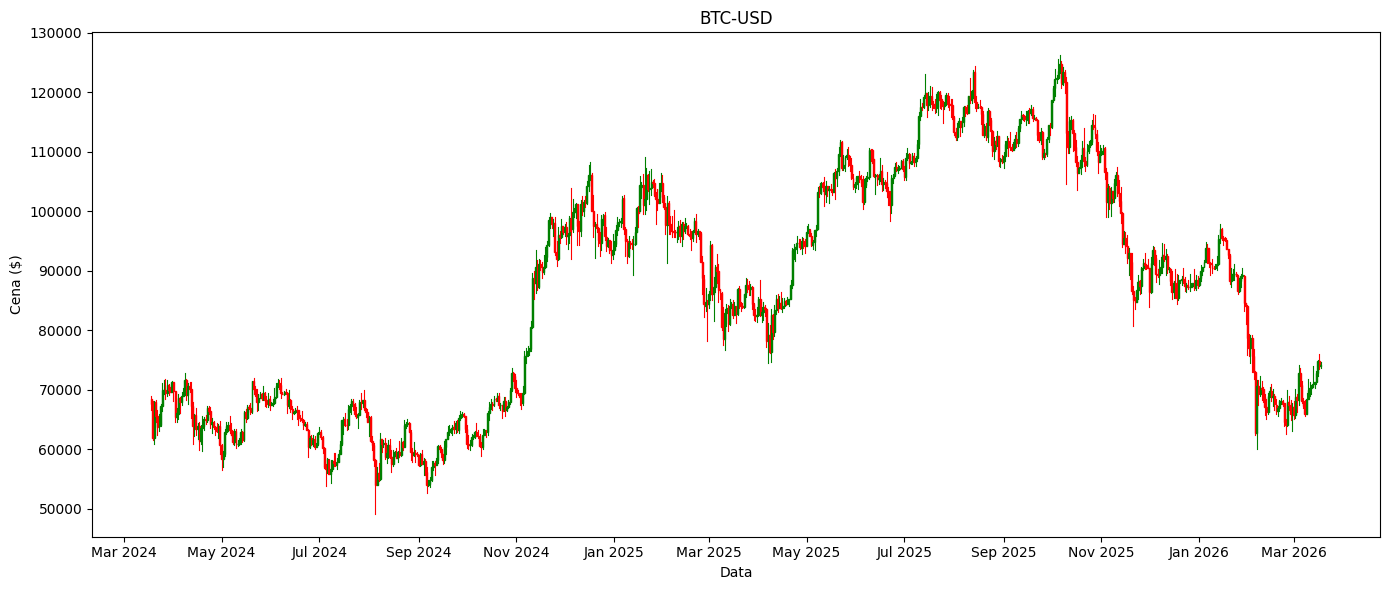

In [98]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

In [108]:
n = 10 #ile swiec sprawdzamy z kazdej strony
df["swing_high"] = np.nan
df["swing_low"] = np.nan

df.loc[argrelextrema(df["High"].values, np.greater_equal, order=n)[0], "swing_high"] = df["High"] # znajdowanie numery wieszy lokalnyh maks
df.loc[argrelextrema(df["Low"].values, np.less_equal, order=n)[0], "swing_low"] = df["Low"] # znajdowanie numery wieszy lokalnyh min

print(f"Swing high: {df['swing_high'].notna().sum()}")
print(f"Swing low:  {df['swing_low'].notna().sum()}")

Swing high: 23
Swing low:  21


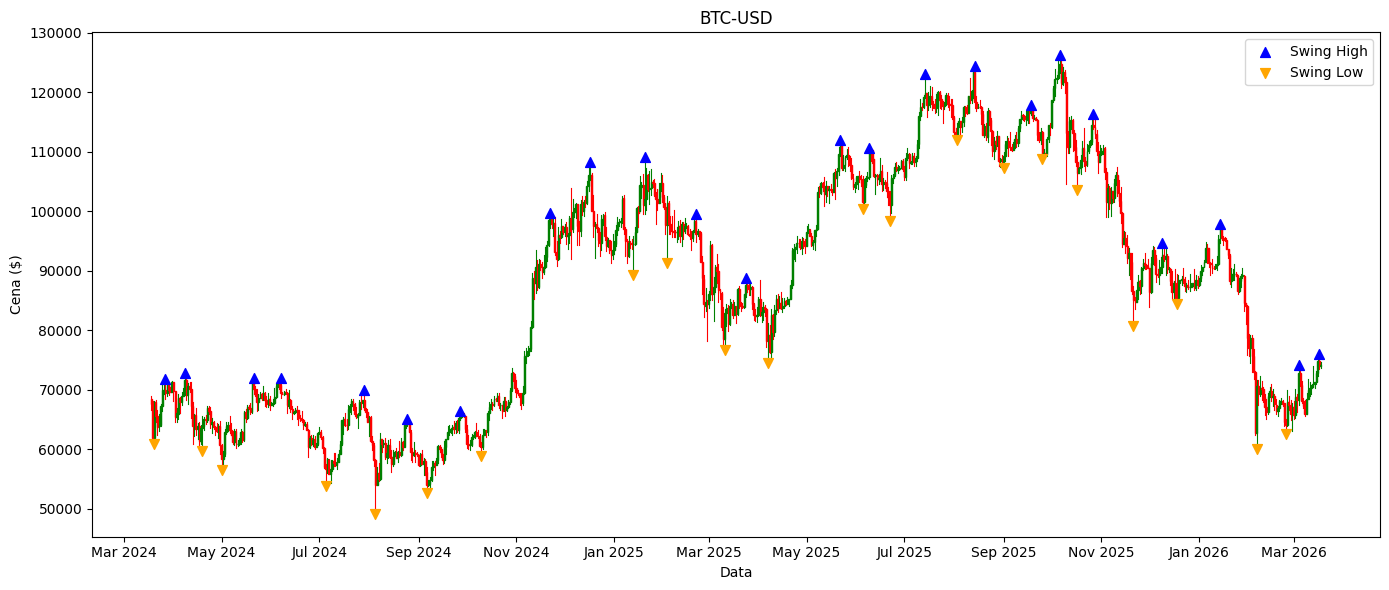

In [109]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

In [110]:
swing_points = []

for i, row in df.iterrows():
    if not np.isnan(row["swing_high"]):
        swing_points.append((row["Date"], row["swing_high"], "high"))
    if not np.isnan(row["swing_low"]):
        swing_points.append((row["Date"], row["swing_low"], "low"))

swing_points.sort(key=lambda x: x[0])

trends = []
for i in range(len(swing_points) - 1):
    a, b = swing_points[i], swing_points[i + 1]
    if a[2] == "low" and b[2] == "high":
        trends.append({"start_date": a[0], "start_price": a[1], "end_date": b[0], "end_price": b[1], "typ": "wzrost"})
    elif a[2] == "high" and b[2] == "low":
        trends.append({"start_date": a[0], "start_price": a[1], "end_date": b[0], "end_price": b[1], "typ": "spadek"})

print(f"Liczba trendów: {len(trends)}")

Liczba trendów: 37


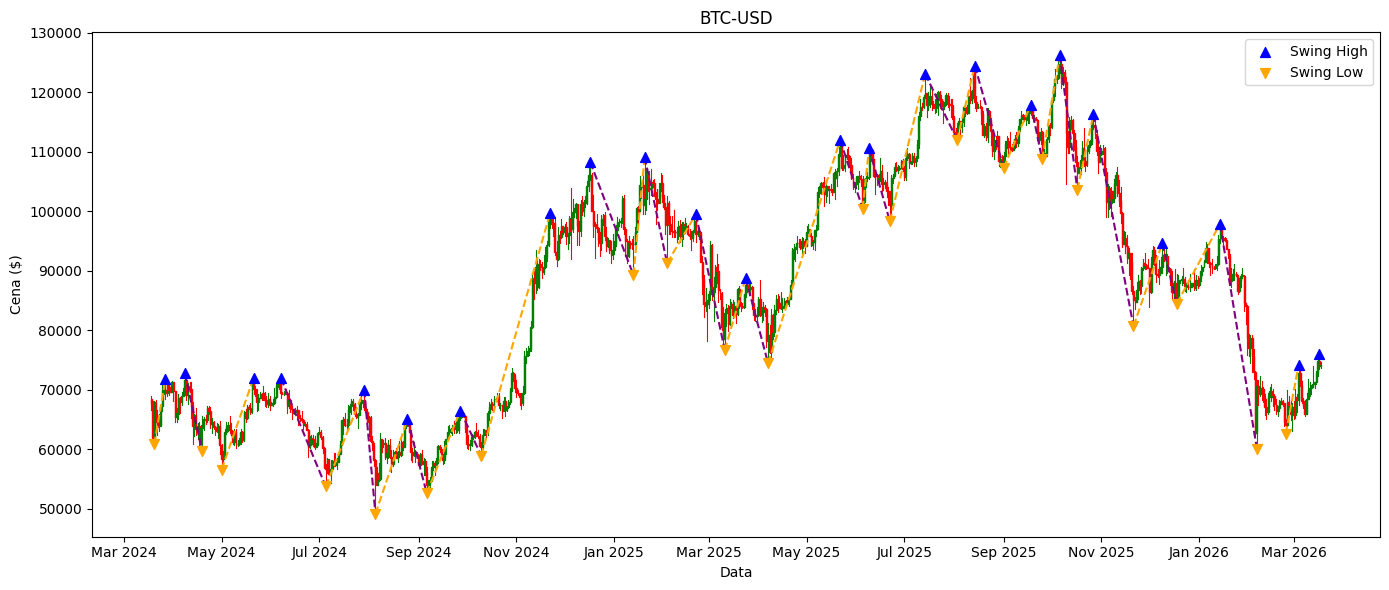

In [112]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()
for t in trends:
    color = "orange" if t["typ"] == "wzrost" else "purple"
    ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]], 
            color=color, linewidth=1.5, linestyle="--")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

In [127]:
#LEVELS = [0, 0.38, 0.5, 0.61, 0.707, 0.878, 1, 1.272, 1.618, 2.058, 2.618, 0.8, 0.236, 0.44, 0.577, 0.667, 0.786, 0.941, 1.13, 1.414, 1.732, 2.236, 0.278, 0.77]
LEVELS = [0.236, 0.382, 0.5, 0.618, 0.786]
fib_zones = []

for t in trends:
    high = t["end_price"] if t["typ"] == "wzrost" else t["start_price"]
    low  = t["start_price"] if t["typ"] == "wzrost" else t["end_price"]
    
    for level in LEVELS:
        price = high - (high - low) * level
        fib_zones.append({
            "start_date": t["start_date"],
            "end_date":   t["end_date"],
            "level":      level,
            "price":      price,
            "typ":        t["typ"]
        })

print(f"Liczba stref: {len(fib_zones)}")
print(fib_zones[:3])

Liczba stref: 185
[{'start_date': Timestamp('2024-03-20 00:00:00'), 'end_date': Timestamp('2024-03-27 00:00:00'), 'level': 0.236, 'price': 69150.590546875, 'typ': 'wzrost'}, {'start_date': Timestamp('2024-03-20 00:00:00'), 'end_date': Timestamp('2024-03-27 00:00:00'), 'level': 0.382, 'price': 67556.2848046875, 'typ': 'wzrost'}, {'start_date': Timestamp('2024-03-20 00:00:00'), 'end_date': Timestamp('2024-03-27 00:00:00'), 'level': 0.5, 'price': 66267.736328125, 'typ': 'wzrost'}]


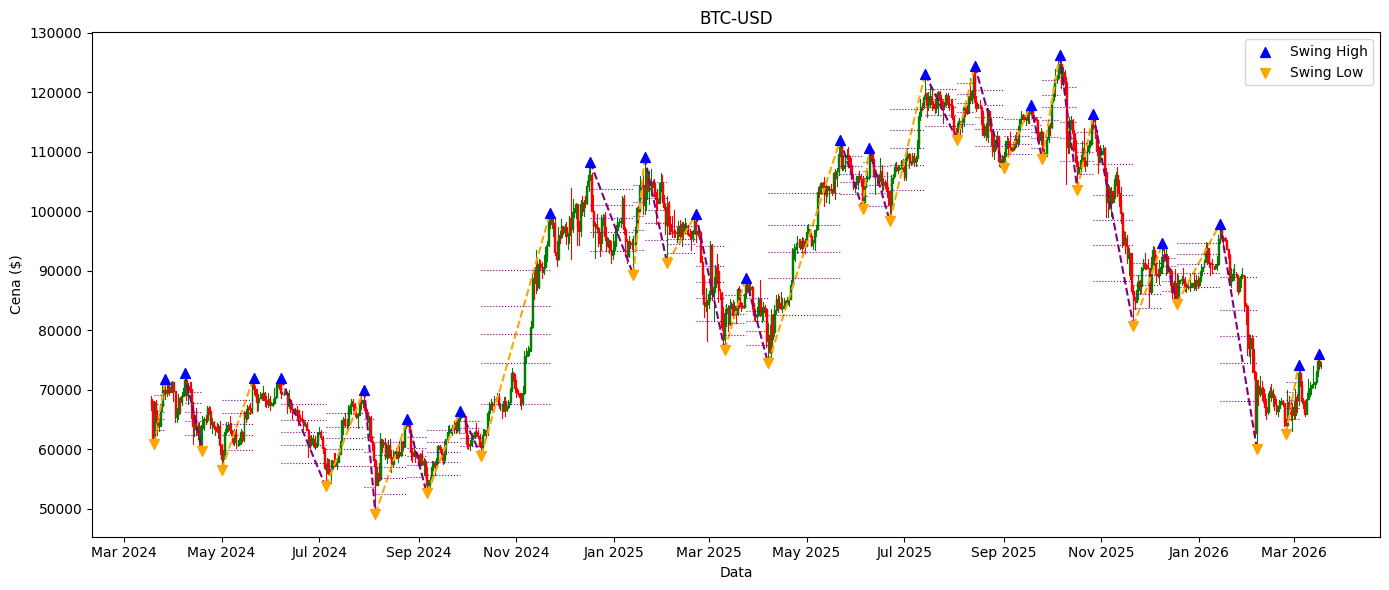

In [128]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()

for t in trends:
    color = "orange" if t["typ"] == "wzrost" else "purple"
    ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]], 
            color=color, linewidth=1.5, linestyle="--")
    
for z in fib_zones:
    ax.hlines(z["price"], z["start_date"], z["end_date"], 
              colors="purple", linewidth=0.8, linestyle=":")
    
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

In [131]:
tolerance = 0.02

def agreguj_strefy(fib_zones, tolerance):
    posortowane = sorted(fib_zones, key=lambda x: x["price"])
    strefy = []
    grupa = [posortowane[0]]

    for z in posortowane[1:]:
        if (z["price"] - grupa[-1]["price"]) / grupa[-1]["price"] < tolerance:
            grupa.append(z)
        else:
            strefy.append({
                "price": np.mean([g["price"] for g in grupa]),
                "typy": list(set([g["typ"] for g in grupa])),
                "poziomy": list(set([g["level"] for g in grupa]))
            })
            grupa = [z]

    strefy.append({
        "price": np.mean([g["price"] for g in grupa]),
        "typy": list(set([g["typ"] for g in grupa])),
        "poziomy": list(set([g["level"] for g in grupa]))
    })
    return strefy

strefy_agregowane = agreguj_strefy(fib_zones, tolerance)
print(f"Liczba stref po agregacji: {len(strefy_agregowane)}")

Liczba stref po agregacji: 7


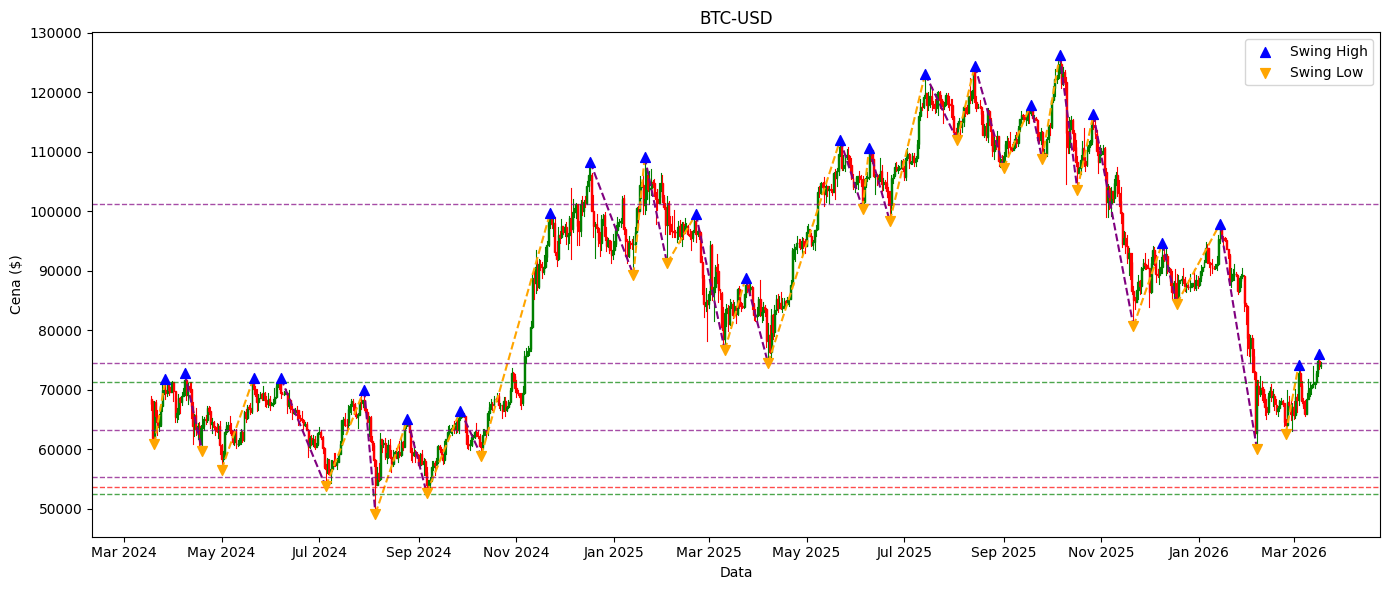

In [132]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()

for t in trends:
    color = "orange" if t["typ"] == "wzrost" else "purple"
    ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]], 
            color=color, linewidth=1.5, linestyle="--")
    
for strefa in strefy_agregowane:
    if "wzrost" in strefa["typy"] and "spadek" in strefa["typy"]:
        kolor = "purple"  # strefa z obu typów trendów - najsilniejsza
    elif "wzrost" in strefa["typy"]:
        kolor = "green"
    else:
        kolor = "red"
    ax.axhline(strefa["price"], color=kolor, linewidth=1, linestyle="--", alpha=0.7)
    
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()